# USRP Test Radio

This notebook captures a short IQ recording from the USRP using `uhd_rx_cfile` and plots a spectrogram so you can quickly verify that the receive chain is alive.

Use this as a first-pass RF sanity check before debugging the main application.

Recommended first tests for 2.4 GHz Wi-Fi:
- `CENTER_FREQ_HZ = 2.412e9`, `2.437e9`, or `2.462e9`
- `ANTENNA = 'RX1'` or `'TX/RX0'` depending on where the antenna is connected
- `GAIN_DB` in the 40 to 60 dB range

In [1]:
from pathlib import Path
import shutil
import subprocess
import numpy as np
import matplotlib.pyplot as plt

CAPTURE_DIR = Path('/tmp/usrp_test_radio')
CAPTURE_DIR.mkdir(parents=True, exist_ok=True)

UHD_ARGS = 'addr=192.168.10.2'
CHANNEL = 0
ANTENNA = 'RX1'
CENTER_FREQ_HZ = 2.437e9
SAMPLE_RATE_HZ = 25e6
GAIN_DB = 50
DURATION_SEC = 0.5
WIRE_FORMAT = 'sc16'
OUTPUT_BASENAME = 'wifi_check_ch0_fc2437MHz'

NSAMPLES = int(SAMPLE_RATE_HZ * DURATION_SEC)
IQ_PATH = CAPTURE_DIR / f'{OUTPUT_BASENAME}.cf32'

print(f'Capture directory: {CAPTURE_DIR}')
print(f'UHD args: {UHD_ARGS}')
print(f'Channel: {CHANNEL}')
print(f'Antenna: {ANTENNA}')
print(f'Center frequency: {CENTER_FREQ_HZ/1e6:.3f} MHz')
print(f'Sample rate: {SAMPLE_RATE_HZ/1e6:.3f} Msps')
print(f'Gain: {GAIN_DB:.1f} dB')
print(f'Duration: {DURATION_SEC:.3f} s')
print(f'Samples: {NSAMPLES}')
print(f'IQ output: {IQ_PATH}')

if shutil.which('uhd_rx_cfile') is None:
    raise RuntimeError('uhd_rx_cfile not found in PATH')

Capture directory: /tmp/usrp_test_radio
UHD args: addr=192.168.10.2
Channel: 0
Antenna: RX1
Center frequency: 2437.000 MHz
Sample rate: 25.000 Msps
Gain: 50.0 dB
Duration: 0.500 s
Samples: 12500000
IQ output: /tmp/usrp_test_radio/wifi_check_ch0_fc2437MHz.cf32


In [2]:
def capture_iq(output_path: Path) -> subprocess.CompletedProcess:

    cmd = [

        'uhd_rx_cfile',

        '--args', UHD_ARGS,

        '--channels', str(CHANNEL),

        '--antenna', ANTENNA,

        '--freq', str(CENTER_FREQ_HZ),

        '--samp-rate', str(SAMPLE_RATE_HZ),

        '--gain', str(GAIN_DB),

        '--nsamples', str(NSAMPLES),

        '--wire-format', WIRE_FORMAT,

        str(output_path),

    ]

    print('Running command:')

    print(' '.join(cmd))

    result = subprocess.run(cmd, capture_output=True, text=True, check=False)

    if result.stdout.strip():

        print('stdout:')

        print(result.stdout)

    if result.stderr.strip():

        print('stderr:')

        print(result.stderr)

    if result.returncode != 0:

        raise RuntimeError(f'uhd_rx_cfile failed with exit code {result.returncode}')

    return result





def load_complex64(path: Path) -> np.ndarray:

    samples = np.fromfile(path, dtype=np.complex64)

    if samples.size == 0:

        raise RuntimeError(f'No samples were written to {path}')

    return samples





def summarize_samples(samples: np.ndarray) -> None:

    power = np.abs(samples) ** 2

    print(f'Loaded {samples.size} complex samples')

    print(f'Mean power: {power.mean():.6f}')

    print(f'Max power: {power.max():.6f}')

    print(f'RMS amplitude: {np.sqrt(power.mean()):.6f}')





def plot_time_power(samples: np.ndarray, sample_rate_hz: float, max_points: int = 200000) -> None:

    if samples.size > max_points:

        stride = int(np.ceil(samples.size / max_points))

        view = samples[::stride]

    else:

        view = samples

    time_ms = np.arange(view.size) / sample_rate_hz * 1e3

    power_db = 10 * np.log10(np.maximum(np.abs(view) ** 2, 1e-12))

    plt.figure(figsize=(12, 3))

    plt.plot(time_ms, power_db, linewidth=0.7)

    plt.xlabel('Time (ms)')

    plt.ylabel('Power (dBFS)')

    plt.title('Received Signal Power vs Time')

    plt.tight_layout()

    plt.show()





def plot_spectrogram(samples: np.ndarray, sample_rate_hz: float, center_freq_hz: float) -> None:

    nfft = 1024

    noverlap = 768

    fig, ax = plt.subplots(figsize=(12, 5))

    _, _, _, image = ax.specgram(

        samples,

        NFFT=nfft,

        Fs=sample_rate_hz / 1e6,

        Fc=center_freq_hz / 1e6,

        noverlap=noverlap,

        scale='dB',

        mode='psd',

        sides='twosided',

        cmap='viridis',

        xextent=(0, samples.size / sample_rate_hz),

    )

    ax.set_xlabel('Time (s)')

    ax.set_ylabel('Frequency (MHz)')

    ax.set_title('USRP Receive Spectrogram')

    fig.colorbar(image, ax=ax, label='PSD (dB)')

    plt.tight_layout()

    plt.show()


Running command:
uhd_rx_cfile --args addr=192.168.10.2 --channels 0 --antenna RX1 --freq 2437000000.0 --samp-rate 25000000.0 --gain 50 --nsamples 12500000 --wire-format sc16 /tmp/usrp_test_radio/wifi_check_ch0_fc2437MHz.cf32
stdout:
usrp_source :warning: Requested sample rate 2.5e+07 Hz not set; instead, 2.4576e+07 Hz used.
vmcircbuf_prefs::get :info: /home/sat3737/.config/gnuradio/prefs/vmcircbuf_default_factory failed to open: bad true, fail true, eof true

stderr:
[INFO] [UHD] linux; GNU C++ version 13.3.0; Boost_108300; UHD_4.7.0.HEAD-0-ga5ed1872
[INFO] [MPMD] Initializing 1 device(s) in parallel with args: mgmt_addr=192.168.10.2,type=x4xx,product=x410,serial=3415B2C,name=ni-x4xx-3415B2C,fpga=X4_200,claimed=False,addr=192.168.10.2
[INFO] [MPM.PeriphManager] init() called with device args `fpga=X4_200,mgmt_addr=192.168.10.2,name=ni-x4xx-3415B2C,product=x410,clock_source=internal,time_source=internal,initializing=True'.
[WARNING] [MULTI_USRP] Could not set RX rate to 25.000 MHz. Actu

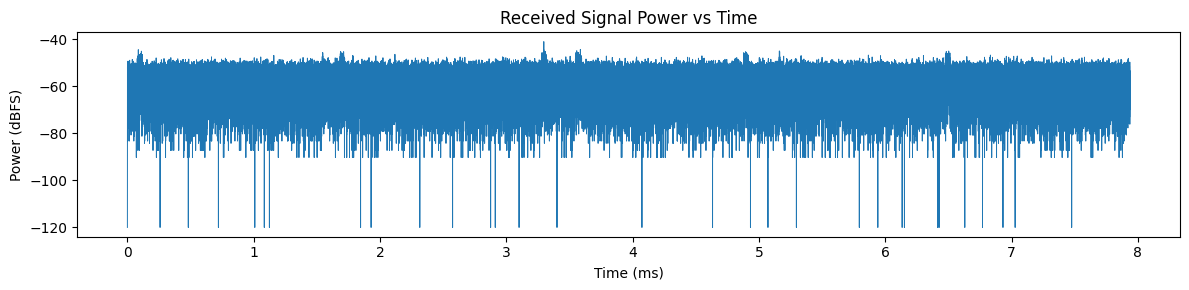

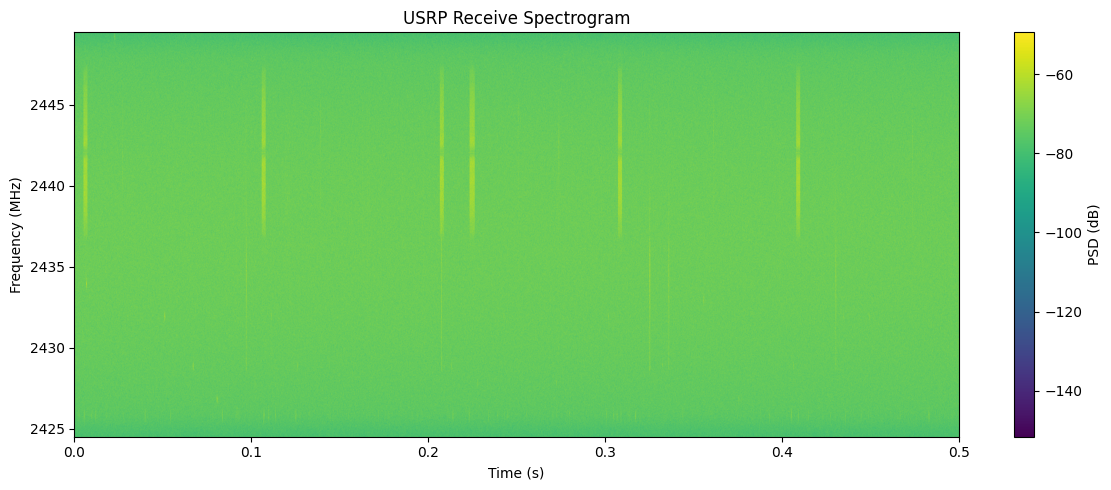

In [3]:
capture_iq(IQ_PATH)
samples = load_complex64(IQ_PATH)
summarize_samples(samples)
plot_time_power(samples, SAMPLE_RATE_HZ)
plot_spectrogram(samples, SAMPLE_RATE_HZ, CENTER_FREQ_HZ)

## Quick troubleshooting

If you only see noise:
- switch `ANTENNA` between `RX1` and `TX/RX0`
- try `CHANNEL = 1` if the antenna is on the other RF frontend
- raise or lower `GAIN_DB` in small steps
- sweep Wi-Fi centers: 2.412, 2.437, and 2.462 GHz
- confirm the antenna is intended for 2.4 GHz